# **Driver drowsiness system**

Dataset Links:
- https://www.kaggle.com/datasets/samymesbah/nthu-dataset-ddd-multi-class

#### **Dataset Downloads**

**Google Colab**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d samymesbah/nthu-dataset-ddd-multi-class

Dataset URL: https://www.kaggle.com/datasets/samymesbah/nthu-dataset-ddd-multi-class
License(s): unknown
100% 1.99G/1.99G [00:30<00:00, 69.4MB/s]



In [5]:
!unzip -q nthu-dataset-ddd-multi-class.zip

**Libraries**

In [6]:
import os
import shutil
import warnings
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

warnings.filterwarnings('ignore')

#### **Rearranging Dataset Directory**

In [7]:
root_dir = "Multi class"
drowsy_dir = "Multi class/train/drowsy"
nondrowsy_dir = "Multi class/train/notdrowsy"

In [8]:
# Moving all classes in drowsy to datasets

for d in os.listdir(drowsy_dir):
    src_path = os.path.join(drowsy_dir, d)
    dst_path = root_dir
    shutil.move(src_path, dst_path)


In [9]:
shutil.move(nondrowsy_dir, root_dir)

'Multi class/notdrowsy'

In [10]:
shutil.rmtree(drowsy_dir)
shutil.rmtree("Multi class/train")

#### **Final Dataset**

In [11]:
parent_dir = "Multi class"

In [12]:
# Count of images in each class

count_of_images = {}
for l in os.listdir(parent_dir):
    count_of_images[l] = len(os.listdir(os.path.join(dst_path, l)))

In [13]:
count_of_images

{'slowBlinkWithNodding': 9412,
 'yawning': 8862,
 'notdrowsy': 30491,
 'sleepyCombination': 17756}

In [14]:
target_counts = {'notdrowsy': 9000, 'sleepyCombination': 9000}

for category, target_count in target_counts.items():
    category_path = os.path.join(parent_dir, category)
    images = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]
    current_count = len(images)

    if current_count > target_count:
        num_to_remove = current_count - target_count
        images_to_remove = random.sample(images, num_to_remove)

        for img_name in images_to_remove:
            os.remove(os.path.join(category_path, img_name))
        print(f"Removed {num_to_remove} images from {category}. New count: {target_count}")
    else:
        print(f"Category {category} already has {current_count} images (less than or equal to target {target_count}). No images removed.")

# Recount the images to verify
count_of_images = {}
for l in os.listdir(parent_dir):
    count_of_images[l] = len(os.listdir(os.path.join(parent_dir, l))) # Note: changed dst_path to parent_dir

print("\nUpdated image counts:")
print(count_of_images)

Removed 21491 images from notdrowsy. New count: 9000
Removed 8756 images from sleepyCombination. New count: 9000

Updated image counts:
{'slowBlinkWithNodding': 9412, 'yawning': 8862, 'notdrowsy': 9000, 'sleepyCombination': 9000}


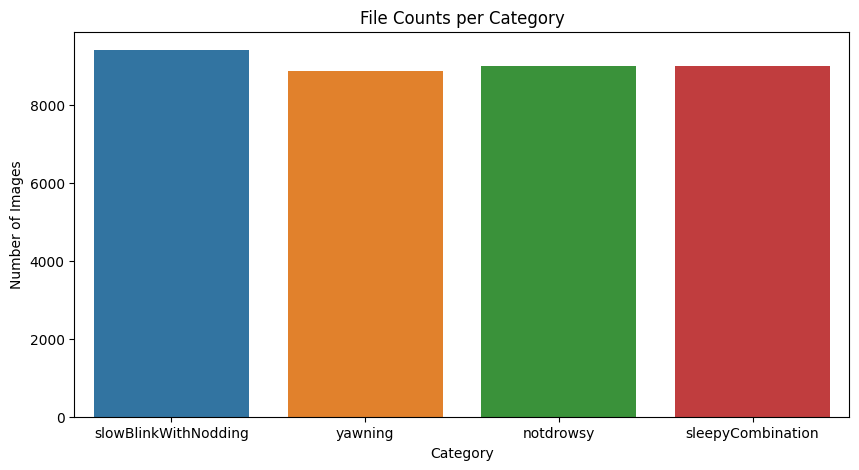

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(x=count_of_images.keys(), y=count_of_images.values(), hue=count_of_images.keys())
plt.title('File Counts per Category')
plt.ylabel('Number of Images')
plt.xlabel('Category')
plt.show()

**Sample Data Visualization**

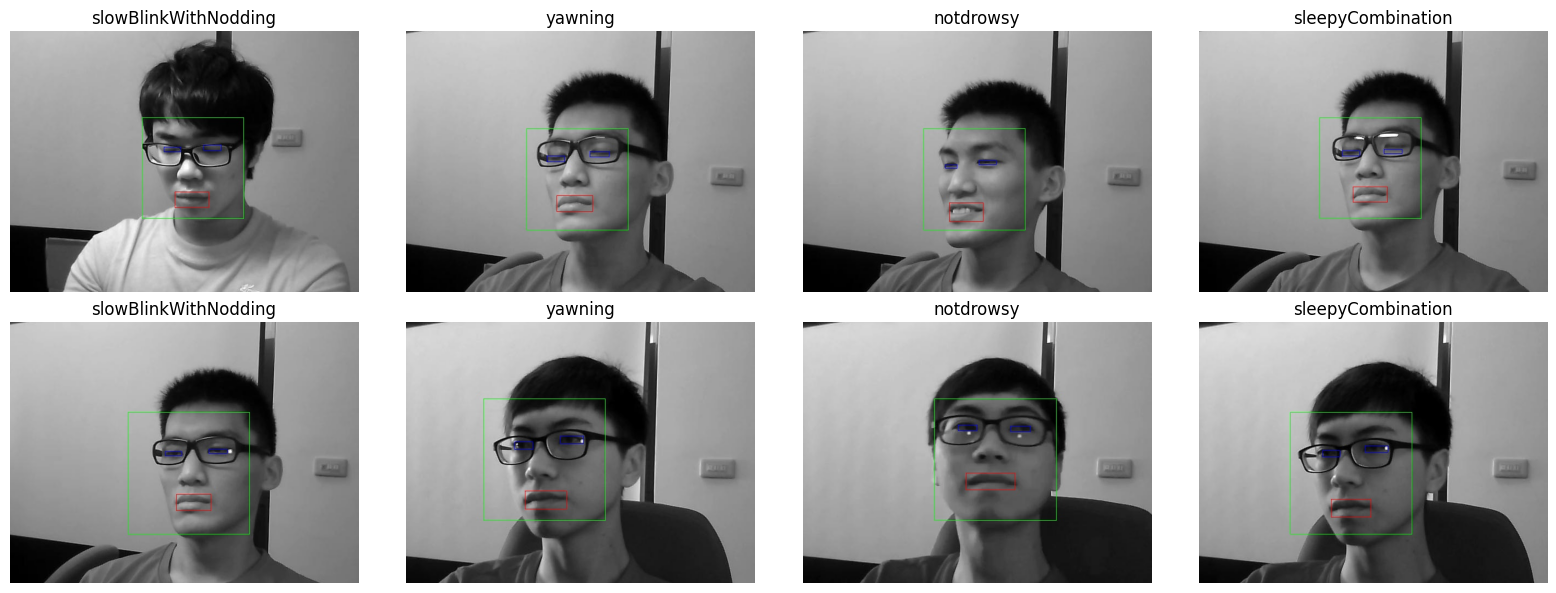

In [16]:
import matplotlib.image as mpimg
dst_path = parent_dir
categories = os.listdir(dst_path)
dir_path = 'Multi class'

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, category in enumerate(categories):
    folder = os.path.join(dir_path, category)
    images = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    sample_imgs = random.sample(images, 2) if len(images) >= 2 else images
    for j, img_name in enumerate(sample_imgs):

        ax = axes[j, i]
        img_path = os.path.join(folder, img_name)
        img = mpimg.imread(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{category}")
        ax.axis('off')

    for j in range(len(sample_imgs), 2):
        axes[j, i].axis('off')

plt.tight_layout()
plt.show()


**Train, Test and Validation**

In [17]:
# Paths
source_dir = "Multi class"
target_dir = "Model Data"

classes = categories

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".jpg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


**Data after train, test and validation split**

In [18]:
train_parent_dir = "Model Data/train"
print("Count of Images for each class in train directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
slowBlinkWithNodding has 6588 images
yawning has 6203 images
notdrowsy has 6300 images
sleepyCombination has 6300 images


In [19]:
val_parent_dir = "Model Data/val"
print("Count of Images for each class in val directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
slowBlinkWithNodding has 1411 images
yawning has 1329 images
notdrowsy has 1350 images
sleepyCombination has 1350 images


In [20]:
test_parent_dir = "Model Data/test"
print("Count of Images for each class in test directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
slowBlinkWithNodding has 1413 images
yawning has 1330 images
notdrowsy has 1350 images
sleepyCombination has 1350 images


#### **Data Augmentation**

In [21]:
train_dir = "Model Data/train"
val_dir = "Model Data/val"
test_dir = "Model Data/test"

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [23]:
img_dims = (128, 128)
batch_size = 64

In [24]:
train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_data.flow_from_directory(
    directory=train_dir,
    target_size= img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

Found 25391 images belonging to 4 classes.


In [25]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

Found 5440 images belonging to 4 classes.


In [26]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5443 images belonging to 4 classes.


In [27]:
train_generator.class_indices

{'notdrowsy': 0,
 'sleepyCombination': 1,
 'slowBlinkWithNodding': 2,
 'yawning': 3}

## **Models**

In [28]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'notdrowsy': 0, 'sleepyCombination': 1, 'slowBlinkWithNodding': 2, 'yawning': 3}

Imbalance Ratio: 1.06


In [29]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(1.0075793650793652), 1: np.float64(1.0075793650793652), 2: np.float64(0.9635321797207043), 3: np.float64(1.0233354828308883)}


In [30]:
class_len = train_generator.num_classes
epochs = 10

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=5)
]

In [32]:
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import random

In [33]:
def evaluate_model(model, name):
    y_true = test_generator.classes
    y_pred = np.argmax(model.predict(test_generator), axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return [name, acc, prec, rec, f1], y_true, y_pred

#### **CNN**

In [34]:
def build_custom_cnn(input_shape=(img_dims[0],img_dims[1],3), num_classes= len(train_generator.class_indices)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(class_len, activation='softmax')
    ])
    return model

In [35]:
custom_model = build_custom_cnn()
custom_model.compile(optimizer=Adam(0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

In [36]:
history_custom = custom_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    # callbacks=callbacks
)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 172s 417ms/step - accuracy: 0.3441 - loss: 1.3382 - val_accuracy: 0.4121 - val_loss: 1.2115
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 157s 394ms/step - accuracy: 0.4845 - loss: 1.1636 - val_accuracy: 0.6004 - val_loss: 1.1858
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 157s 396ms/step - accuracy: 0.5684 - loss: 0.9973 - val_accuracy: 0.6412 - val_loss: 0.9090
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 157s 397ms/step - accuracy: 0.6202 - loss: 0.8989 - val_accuracy: 0.7061 - val_loss: 0.7678
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 160s 402ms/step - accuracy: 0.6610 - loss: 0.8216 - val_accuracy: 0.7485 - val_loss: 0.6934
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 157s 394ms/step - accuracy: 0.6912 - loss: 0.7613 - val_accuracy: 0.7171 - val_loss: 0.7315
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 161s 406ms/step - accuracy: 0.7170 - loss: 0.7034 - val_accuracy: 0.7564 - val_loss: 0.6479
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 160s 402ms/step - accuracy: 0.7325 -

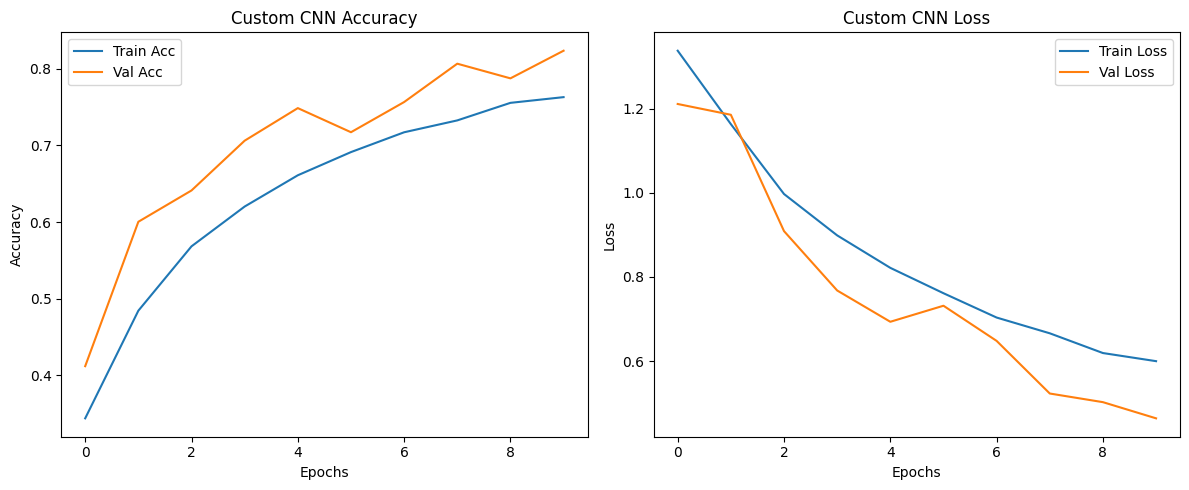

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_custom.history['accuracy'], label='Train Acc')
axes[0].plot(history_custom.history['val_accuracy'], label='Val Acc')
axes[0].set_title("Custom CNN Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_custom.history['loss'], label='Train Loss')
axes[1].plot(history_custom.history['val_loss'], label='Val Loss')
axes[1].set_title("Custom CNN Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [38]:
model_results = []

cnn_metrics, y_true, y_pred_cnn = evaluate_model(custom_model, "Custom CNN")
model_results.append(cnn_metrics)

86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step


#### **DenseNet201**

In [39]:
from tensorflow.keras.applications import DenseNet201

In [40]:
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_dims[0], img_dims[1], 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(class_len, activation='softmax')(x)

densenet_model = Model(inputs=base_model.input, outputs=x)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
densenet_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [42]:
history_dense = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 277s 577ms/step - accuracy: 0.5058 - loss: 1.1423 - val_accuracy: 0.6472 - val_loss: 0.8536
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 172s 434ms/step - accuracy: 0.6280 - loss: 0.8914 - val_accuracy: 0.7434 - val_loss: 0.7040
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 165s 415ms/step - accuracy: 0.6700 - loss: 0.8041 - val_accuracy: 0.7838 - val_loss: 0.6273
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 165s 416ms/step - accuracy: 0.6877 - loss: 0.7669 - val_accuracy: 0.7629 - val_loss: 0.6506
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 174s 439ms/step - accuracy: 0.7109 - loss: 0.7149 - val_accuracy: 0.8031 - val_loss: 0.5484
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 177s 446ms/step - accuracy: 0.7267 - loss: 0.6845 - val_accuracy: 0.8092 - val_loss: 0.5618
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 171s 431ms/step - accuracy: 0.7302 - loss: 0.6681 - val_accuracy: 0.8116 - val_loss: 0.5270
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 169s 425ms/step - accuracy: 0.7415 -

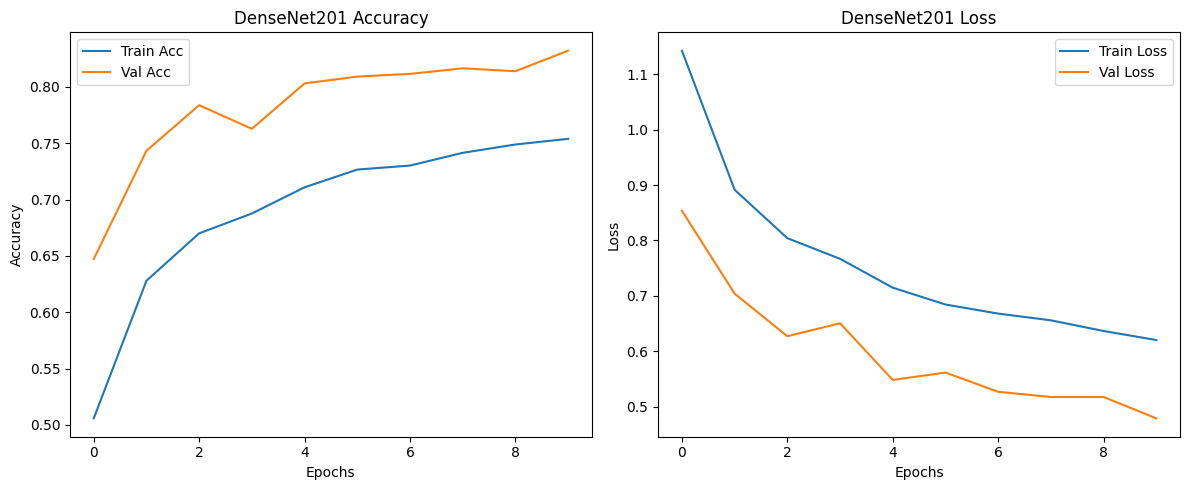

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_dense.history['accuracy'], label='Train Acc')
axes[0].plot(history_dense.history['val_accuracy'], label='Val Acc')
axes[0].set_title("DenseNet201 Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_dense.history['loss'], label='Train Loss')
axes[1].plot(history_dense.history['val_loss'], label='Val Loss')
axes[1].set_title("DenseNet201 Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [44]:
dense_metrics, _, y_pred_dense = evaluate_model(densenet_model, "DenseNet201")
model_results.append(dense_metrics)

86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 444ms/step


#### **Finetuned DenseNet 201**

In [45]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [46]:
densenet_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [47]:
history_dense_ft = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights
)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 273s 552ms/step - accuracy: 0.7006 - loss: 0.7572 - val_accuracy: 0.8325 - val_loss: 0.4806
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 164s 413ms/step - accuracy: 0.7584 - loss: 0.6216 - val_accuracy: 0.8412 - val_loss: 0.4499
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 166s 419ms/step - accuracy: 0.7757 - loss: 0.5792 - val_accuracy: 0.8423 - val_loss: 0.4402
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 172s 432ms/step - accuracy: 0.7826 - loss: 0.5627 - val_accuracy: 0.8489 - val_loss: 0.4211
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 166s 419ms/step - accuracy: 0.7935 - loss: 0.5464 - val_accuracy: 0.8526 - val_loss: 0.4143
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 165s 416ms/step - accuracy: 0.7958 - loss: 0.5279 - val_accuracy: 0.8579 - val_loss: 0.4018
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 164s 414ms/step - accuracy: 0.8069 - loss: 0.5119 - val_accuracy: 0.8540 - val_loss: 0.4072
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 162s 408ms/step - accuracy: 0.8095 -

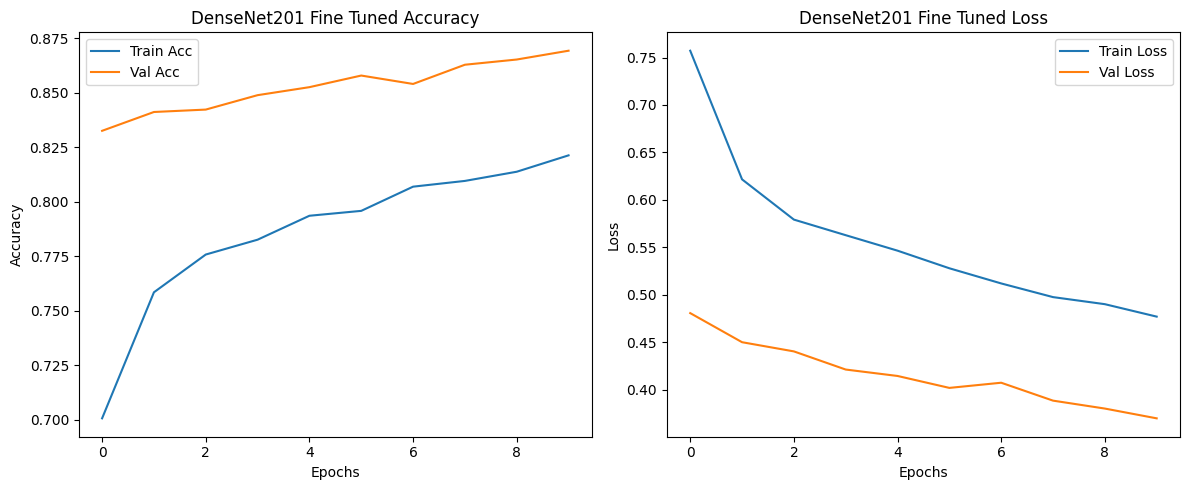

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Plot
axes[0].plot(history_dense_ft.history['accuracy'], label='Train Acc')
axes[0].plot(history_dense_ft.history['val_accuracy'], label='Val Acc')
axes[0].set_title("DenseNet201 Fine Tuned Accuracy")
axes[0].legend()
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")

# Loss Plot
axes[1].plot(history_dense_ft.history['loss'], label='Train Loss')
axes[1].plot(history_dense_ft.history['val_loss'], label='Val Loss')
axes[1].set_title("DenseNet201 Fine Tuned Loss")
axes[1].legend()
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [49]:
dense_ft_metrics, _, y_pred_dense_ft = evaluate_model(densenet_model, "Fine Tuned DenseNet201")
model_results.append(dense_ft_metrics)

86/86 ━━━━━━━━━━━━━━━━━━━━ 59s 423ms/step


## **Metrics**

In [50]:
df_results = pd.DataFrame(model_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
df_results

,Model,Accuracy,Precision,Recall,F1
0,Custom CNN,0.828587,0.828391,0.828587,0.825789
1,DenseNet201,0.830057,0.834881,0.830057,0.825504
2,Fine Tuned DenseNet201,0.873415,0.879366,0.873415,0.868179


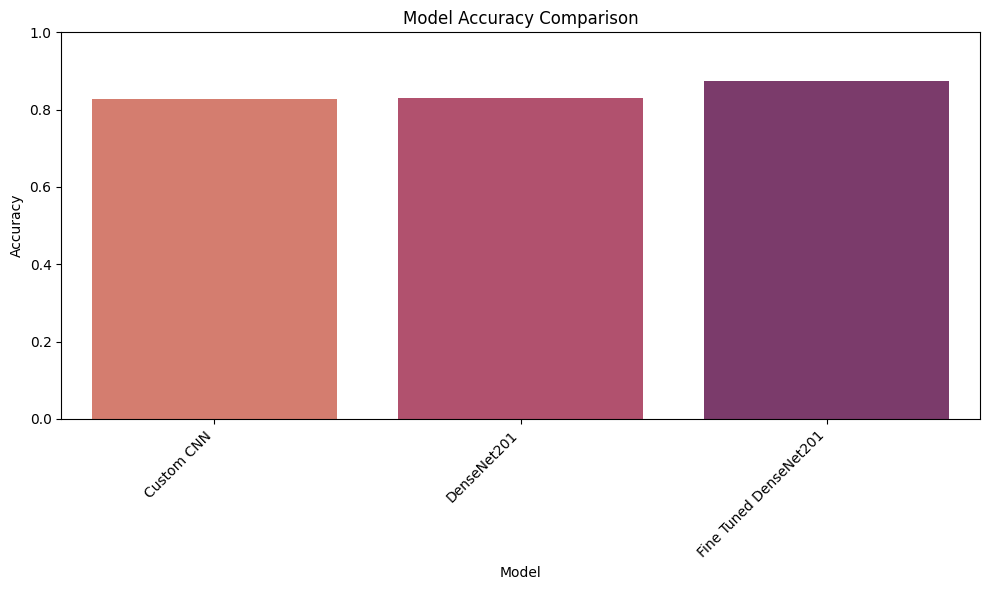

In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=df_results, palette='flare')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

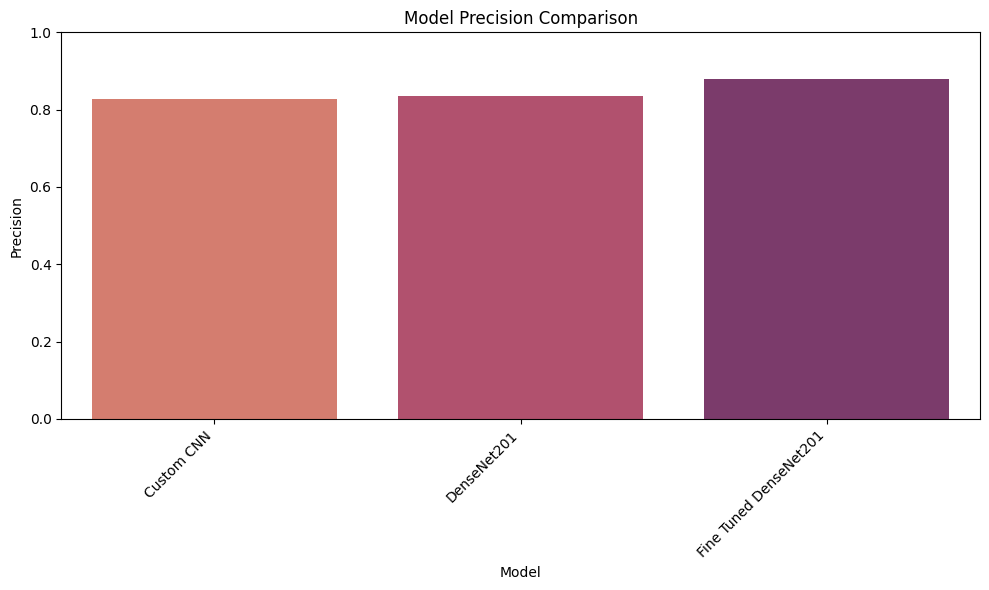

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Precision', data=df_results, palette='flare')
plt.title('Model Precision Comparison')
plt.xlabel('Model')
plt.ylabel('Precision')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

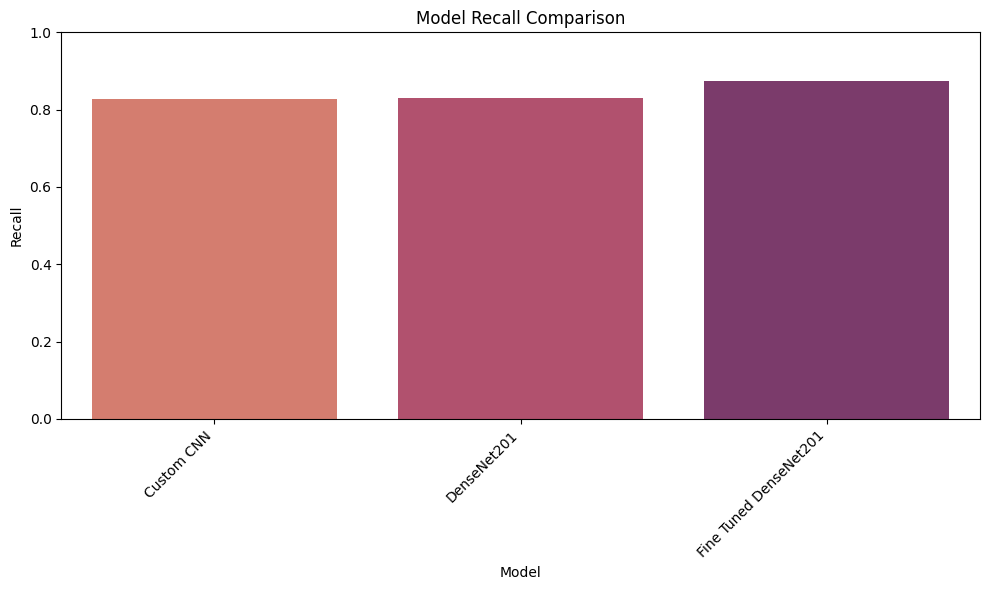

In [53]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Recall', data=df_results, palette='flare')
plt.title('Model Recall Comparison')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

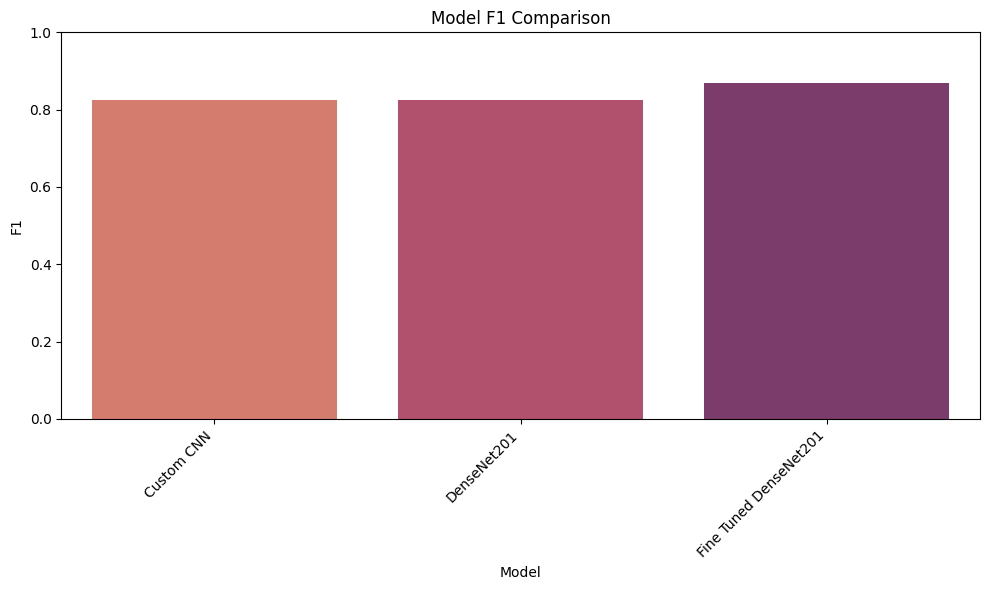

In [54]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1', data=df_results, palette='flare')
plt.title('Model F1 Comparison')
plt.xlabel('Model')
plt.ylabel('F1')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Confusion Matrix**

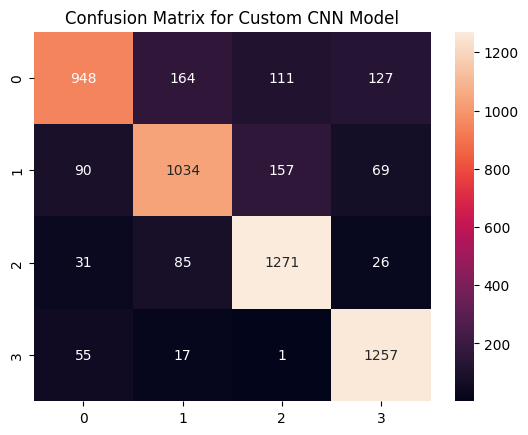

In [55]:
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

sns.heatmap(cm_cnn, annot=True, fmt='d')
plt.title("Confusion Matrix for Custom CNN Model")
plt.show()

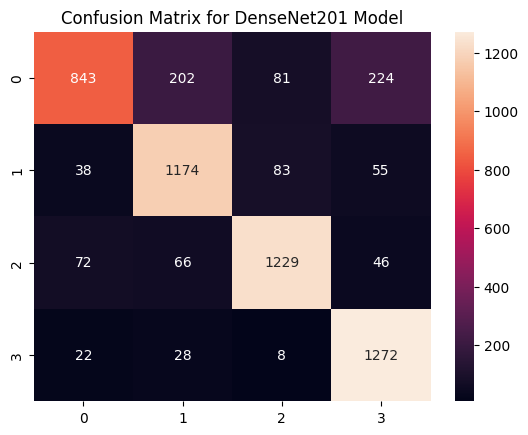

In [57]:
cm_dense = confusion_matrix(y_true, y_pred_dense)

sns.heatmap(cm_dense, annot=True, fmt='d')
plt.title("Confusion Matrix for DenseNet201 Model")
plt.show()

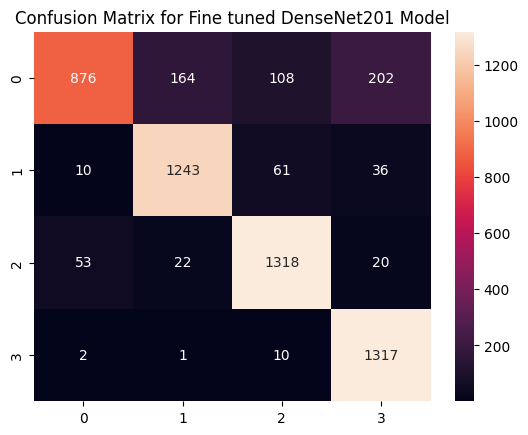

In [58]:
cm_dense_ft = confusion_matrix(y_true, y_pred_dense_ft)

sns.heatmap(cm_dense_ft, annot=True, fmt='d')
plt.title("Confusion Matrix for Fine tuned DenseNet201 Model")
plt.show()


## **ROC Curve**

86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 151ms/step


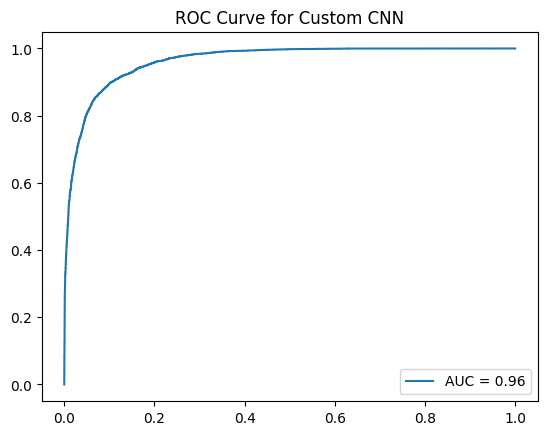

In [59]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = custom_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for Custom CNN")
plt.show()

86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 137ms/step


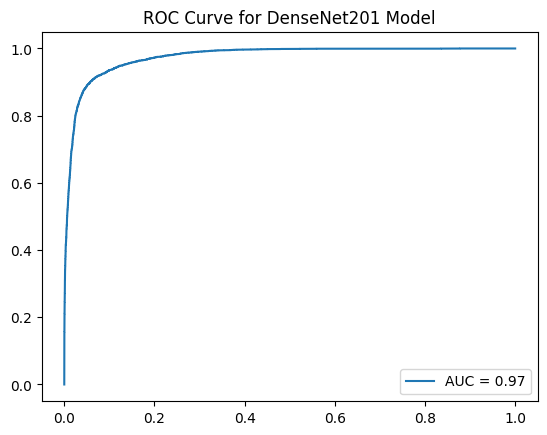

In [60]:
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = densenet_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC Curve for DenseNet201 Model")
plt.show()

## **Test Predictions**

In [61]:
best_model_name = df_results.sort_values(by="F1", ascending=False).iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Fine Tuned DenseNet201


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 


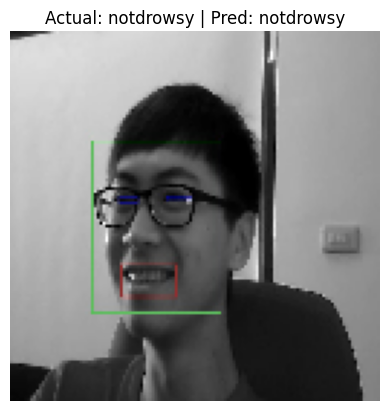

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


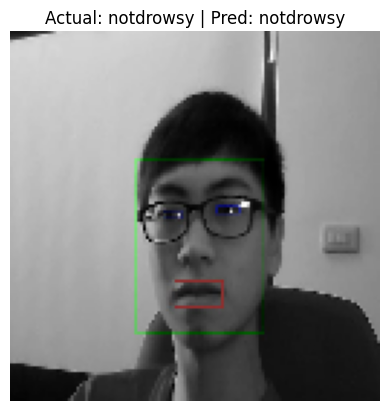

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


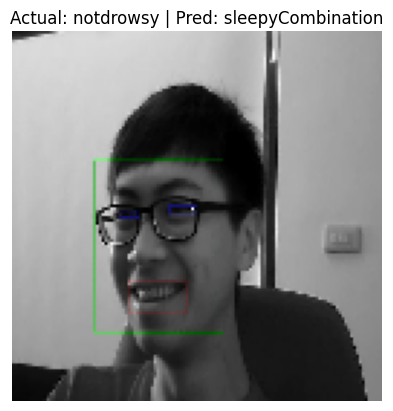

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


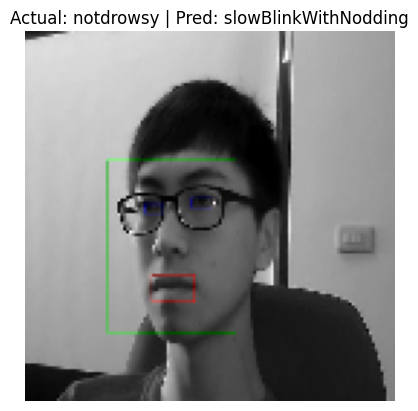

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


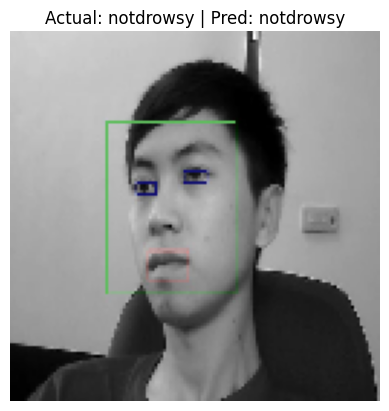

In [62]:
class_labels = list(test_generator.class_indices.keys())
best_model = custom_model
for i in range(5):
    img, label = test_generator[i]
    pred = best_model.predict(img)

    plt.imshow(img[0])
    plt.title(f"Actual: {class_labels[np.argmax(label[0])]} | Pred: {class_labels[np.argmax(pred[0])]}")
    plt.axis('off')
    plt.show()

## **Grad-CAM**

In [63]:
def grad_cam(model, img_array, layer_name):
    # Ensure model is called
    _ = model(img_array)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model(model.inputs)]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        # Explicitly watch conv_outputs to ensure gradients are computed
        tape.watch(conv_outputs)

        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    # Handle case where gradients are not computed (e.g., if path is broken)
    if grads is None:
        # Fallback to zeros or raise an error, depending on desired behavior
        return tf.zeros_like(conv_outputs[0][..., 0]) # Return an all-zero heatmap

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    # Normalize heatmap, handle potential division by zero
    max_heatmap_val = tf.reduce_max(heatmap)
    if max_heatmap_val != 0:
        heatmap /= max_heatmap_val
    else:
        heatmap = tf.zeros_like(heatmap) # If all zeros, keep it zeros

    return heatmap

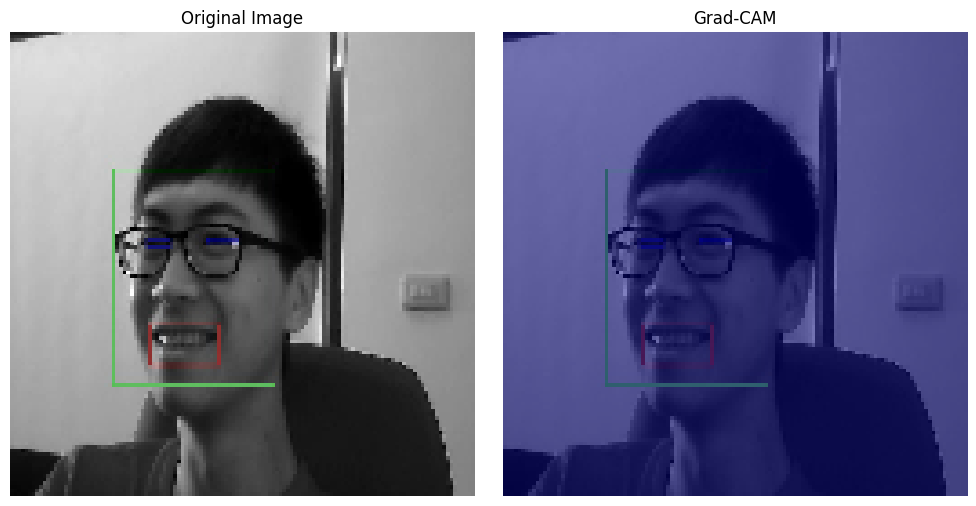

In [64]:
# Get single image
img, _ = test_generator[0]
img = img[0:1]

# Generate heatmap
heatmap = grad_cam(best_model, img, layer_name="conv2d_2")

# Resize heatmap
import cv2
heatmap = cv2.resize(heatmap.numpy(), (img.shape[2], img.shape[1]))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img[0])
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(img[0])
axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
axes[1].set_title("Grad-CAM")
axes[1].axis('off')

plt.tight_layout()
plt.show()